
================ LINEAR REGRESSION =================

First few rows of housing dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


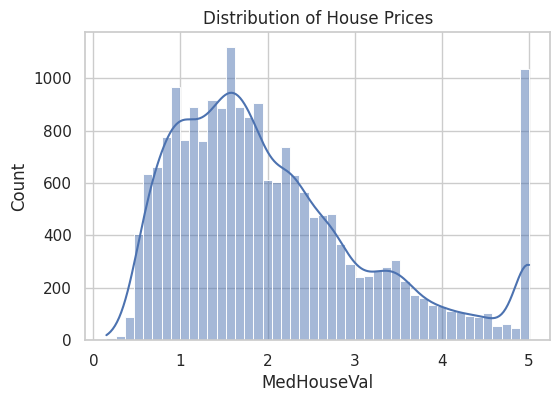


Linear Regression Performance:
Mean Squared Error: 0.5558915986952444

Linear Regression Coefficients:
      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

sns.set(style="whitegrid")

# =====================================================
# PART 1: LINEAR REGRESSION (House Prices)
# =====================================================

print("\n================ LINEAR REGRESSION =================\n")

# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("First few rows of housing dataset:")
print(df.head())

# Distribution of target
plt.figure(figsize=(6,4))
sns.histplot(df["MedHouseVal"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

# Train-test split
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

# Evaluation
print("\nLinear Regression Performance:")
# print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lin_model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nLinear Regression Coefficients:")
print(coefficients)

# # Residual plot
# residuals = y_test - y_pred
# plt.figure(figsize=(6,4))
# sns.scatterplot(x=y_pred, y=residuals)
# plt.axhline(0, color='red')
# plt.xlabel("Predicted Price")
# plt.ylabel("Residual")
# plt.title("Residual Plot")
# plt.show()





================ LOGISTIC REGRESSION =================

   Tenure  MonthlyCharges  TechSupport  ContractType  Churn
0      39       76.241392            0             1      0
1      52       72.998633            1             0      0
2      29       57.601316            1             1      0
3      15      118.147552            1             0      1
4      43       73.451882            1             1      0


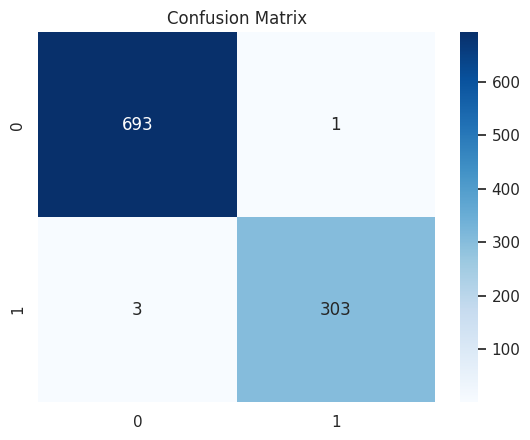


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       694
           1       1.00      0.99      0.99       306

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
# =====================================================
# PART 2: LOGISTIC REGRESSION (Customer Churn)
# =====================================================

print("\n================ LOGISTIC REGRESSION =================\n")

np.random.seed(42)
n = 5000

# Generate synthetic churn dataset
df_churn = pd.DataFrame({
    "Tenure": np.random.randint(1, 60, n),
    "MonthlyCharges": np.random.normal(70, 20, n),
    "TechSupport": np.random.binomial(1, 0.5, n),
    "ContractType": np.random.binomial(1, 0.6, n)
})

# Create churn probability (realistic pattern)
logit = (
    -0.05 * df_churn["Tenure"] +
    0.03 * df_churn["MonthlyCharges"] -
    1.0 * df_churn["TechSupport"] -
    1.2 * df_churn["ContractType"]
)

# prob = 1 / (1 + np.exp(-logit))
# df_churn["Churn"] = np.random.binomial(1, prob)

prob = 1 / (1 + np.exp(-logit))
df_churn["Churn"] = (prob > 0.5).astype(int)

print(df_churn.head())

# Split
X = df_churn.drop("Churn", axis=1)
y = df_churn["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit logistic model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# # ROC Curve
# fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# plt.plot(fpr, tpr)
# plt.plot([0,1],[0,1],'--')
# plt.title("ROC Curve")
# plt.show()

# print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# # Odds Ratios
# odds_ratios = pd.DataFrame({
#     "Feature": X.columns,
#     "Odds_Ratio": np.exp(log_model.coef_[0])
# }).sort_values(by="Odds_Ratio", ascending=False)

# print("\nOdds Ratios:")
# print(odds_ratios)
